# The Product Pricer Continued

A model that can estimate how much something costs, from its description.

## AT LAST - it's time for Fine Tuning!

After all this data preparation, and old school machine learning, we've finally arrived at the moment you've been waiting for. Fine-tuning a model.

In [ ]:
# imports

import os
import re
# import math
import json
# import random
from dotenv import load_dotenv
from huggingface_hub import login
# from items import Item
# import matplotlib.pyplot as plt
import numpy as np
import pickle
# from collections import Counter
from openai import OpenAI
# from anthropic import Anthropic

In [4]:
# moved our Tester into a separate package
# call it with Tester.test(function_name, test_dataset)

from testing import Tester

In [5]:
# environment

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')

In [6]:
# Log in to HuggingFace

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [7]:
openai = OpenAI()

In [8]:
%matplotlib inline

In [9]:
# Let's avoid curating all our data again! Load in the pickle files:

with open('train_lite.pkl', 'rb') as file:
    train = pickle.load(file)

with open('test_lite.pkl', 'rb') as file:
    test = pickle.load(file)

In [10]:
# OpenAI recommends fine-tuning with populations of 50-100 examples
# But as our examples are very small, I'm suggesting we go with 500 examples (and 1 epoch)

fine_tune_train = train[:500]
fine_tune_validation = train[500:550]

# Step 1

Prepare our data for fine-tuning in JSONL (JSON Lines) format and upload to OpenAI

In [11]:
# First let's work on a good prompt for a Frontier model
# Notice that I'm removing the " to the nearest dollar"
# When we train our own models, we'll need to make the problem as easy as possible, 
# but a Frontier model needs no such simplification.

def messages_for(item):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": f"Price is ${item.price:.2f}"}
    ]

In [12]:
# Convert the items into a list of json objects - a "jsonl" string
# Each row represents a message in the form:
# {"messages" : [{"role": "system", "content": "You estimate prices...


def make_jsonl(items):
    result = ""
    for item in items:
        messages = messages_for(item)
        messages_str = json.dumps(messages)
        result += '{"messages": ' + messages_str +'}\n'
    return result.strip()

In [13]:
# Convert the items into jsonl and write them to a file

def write_jsonl(items, filename):
    with open(filename, "w") as f:
        jsonl = make_jsonl(items)
        f.write(jsonl)

In [14]:
write_jsonl(fine_tune_train, "fine_tune_train.jsonl")

In [15]:
write_jsonl(fine_tune_validation, "fine_tune_validation.jsonl")

In [16]:
with open("fine_tune_train.jsonl", "rb") as f:
    train_file = openai.files.create(file=f, purpose="fine-tune")

In [17]:
train_file

FileObject(id='file-EBPvDKxKgB6B4YdPXbrrZD', bytes=471587, created_at=1748066227, filename='fine_tune_train.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None)

In [18]:
with open("fine_tune_validation.jsonl", "rb") as f:
    validation_file = openai.files.create(file=f, purpose="fine-tune")

In [19]:
validation_file

FileObject(id='file-WaK6fRKktFnposYdxpdKH9', bytes=46530, created_at=1748066228, filename='fine_tune_validation.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None)

# Step 2

I love Weights and Biases - a beautiful, free platform for monitoring training runs.  
Weights and Biases is integrated with OpenAI for fine-tuning.

First set up your weights & biases free account at:

https://wandb.ai

From the Avatar >> Settings menu, near the bottom, you can create an API key.

Then visit the OpenAI dashboard at:

https://platform.openai.com/account/organization

In the integrations section, you can add your Weights & Biases key.

## And now time to Fine-tune!

In [20]:
wandb_integration = {"type": "wandb", "wandb": {"project": "gpt-pricer"}}

In [21]:
openai.fine_tuning.jobs.create(
    training_file=train_file.id,
    validation_file=validation_file.id,
    model="gpt-4o-mini-2024-07-18",
    seed=42,
    hyperparameters={"n_epochs": 1},
    integrations = [wandb_integration],
    suffix="pricer"
)

FineTuningJob(id='ftjob-ocT5OkR71CZYEgW1MvDU1WnV', created_at=1748066232, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-Bn5JlSrY30cBMzxc92D4pPMl', result_files=[], seed=42, status='validating_files', trained_tokens=None, training_file='file-EBPvDKxKgB6B4YdPXbrrZD', validation_file='file-WaK6fRKktFnposYdxpdKH9', estimated_finish=None, integrations=[FineTuningJobWandbIntegrationObject(type='wandb', wandb=FineTuningJobWandbIntegration(project='gpt-pricer', entity=None, name=None, tags=None, run_id='ftjob-ocT5OkR71CZYEgW1MvDU1WnV'))], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1))), user_provided_suffix='price

In [22]:
openai.fine_tuning.jobs.list(limit=1)

SyncCursorPage[FineTuningJob](data=[FineTuningJob(id='ftjob-ocT5OkR71CZYEgW1MvDU1WnV', created_at=1748066232, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-Bn5JlSrY30cBMzxc92D4pPMl', result_files=[], seed=42, status='validating_files', trained_tokens=None, training_file='file-EBPvDKxKgB6B4YdPXbrrZD', validation_file='file-WaK6fRKktFnposYdxpdKH9', estimated_finish=None, integrations=[FineTuningJobWandbIntegrationObject(type='wandb', wandb=FineTuningJobWandbIntegration(project='gpt-pricer', entity=None, name=None, tags=None, run_id='ftjob-ocT5OkR71CZYEgW1MvDU1WnV'))], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epoc

### Reused Fine Tune Model in OpenAI Fine Tune 

In [23]:
index = 2
jobs = openai.fine_tuning.jobs.list(limit=50).data

if len(jobs) > index:
    job_id1 = jobs[index - 1 ].id
    fine_tuned_model1 = jobs[index - 1].fine_tuned_model
else:
    job_id1 = None
    fine_tuned_model1 = None
    print(f"⚠️ jobs[{index - 1}] does not exist (list too short).")

In [25]:
# job_id = openai.fine_tuning.jobs.list(limit=1).data[0].id
if job_id1 == None:
    job_id = openai.fine_tuning.jobs.list(limit=1).data[0].id
else:
    job_id = job_id1

In [26]:
job_id

'ftjob-xVDh5Cxk47b3IcIl4fhBB3QF'

In [27]:
openai.fine_tuning.jobs.retrieve(job_id)

FineTuningJob(id='ftjob-xVDh5Cxk47b3IcIl4fhBB3QF', created_at=1748058187, error=Error(code=None, message=None, param=None), fine_tuned_model='ft:gpt-4o-mini-2024-07-18:personal:pricer:BaaF7IUR', finished_at=1748058823, hyperparameters=Hyperparameters(batch_size=1, learning_rate_multiplier=1.8, n_epochs=1), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-Bn5JlSrY30cBMzxc92D4pPMl', result_files=['file-Rnzp6Pgk8YyMaADxmTPtjM'], seed=42, status='succeeded', trained_tokens=39247, training_file='file-4uEMmx3ayte9Mya9P9aCRF', validation_file='file-2geStvcu4oxLuv3n9vofe7', estimated_finish=None, integrations=[FineTuningJobWandbIntegrationObject(type='wandb', wandb=FineTuningJobWandbIntegration(project='gpt-pricer', entity=None, name=None, tags=None, run_id='ftjob-xVDh5Cxk47b3IcIl4fhBB3QF'))], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size=1, learning_ra

In [28]:
openai.fine_tuning.jobs.list_events(fine_tuning_job_id=job_id, limit=10).data

[FineTuningJobEvent(id='ftevent-avkgB0aXYSt15GmeKfnHG831', created_at=1748059589, level='info', message='The job has successfully completed', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-TC6N4lNNKGS6k8KpGp6P97Ac', created_at=1748059585, level='info', message='Usage policy evaluations completed, model is now enabled for sampling', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-ECwePFGGfoytEoyeXwg6Sx8D', created_at=1748058826, level='info', message='Evaluating model against our usage policies before enabling', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-TOjpDoT0nrWxLZMOUoJInBM5', created_at=1748058826, level='info', message='New fine-tuned model created', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-5lybTJycI56k0uWvcvSw45lB', created_at=1748058764, level='info', message='Step 200/200: training loss=0.56, validat

# Step 3

Test our fine tuned model

In [29]:
fine_tuned_model_name = openai.fine_tuning.jobs.retrieve(job_id).fine_tuned_model
print(fine_tuned_model_name)

ft:gpt-4o-mini-2024-07-18:personal:pricer:BaaF7IUR


In [30]:
# The prompt

def messages_for(item):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": "Price is $"}
    ]

In [31]:
# Try this out

messages_for(test[0])

[{'role': 'system',
  'content': 'You estimate prices of items. Reply only with the price, no explanation'},
 {'role': 'user',
  'content': "How much does this cost?\n\nBLACK High Temperature Header Exhaust Pipe Insulation Wrap Roll Black 1/16 X 2 X 50' - Thermal Zero\nWidth (in) 2 in Length (ft) 50 feet Wrap Material Thermal Fiber Wrap Color Black Temperature Rating (degrees F) 2000 degree Fahrenheit Instillation Stainless Ties (sold separately) Thickness (in) 1/16 (.063 in) Quantity 1 Roll Thermal Zero header wraps utilizes our own thermal technology to provide superior protection from heat that may exit the exhaust pipe. They lower engine bay temperatures and help to create more horsepower. Our wrap can withstand temperatures of up 2000 degrees Fahrenheit. The wraps provide great protection for motorcycle pipes, while also creating that old school look. Our wraps contain NO ASBESTOS. High temperature exhaust wrap can"},
 {'role': 'assistant', 'content': 'Price is $'}]

In [32]:
# A utility function to extract the price from a string

def get_price(s):
    s = s.replace('$','').replace(',','')
    match = re.search(r"[-+]?\d*\.\d+|\d+", s)
    return float(match.group()) if match else 0

In [33]:
get_price("The price is roughly $99.99 because blah blah")

99.99

In [34]:
# The function for gpt-4o-mini

def gpt_fine_tuned(item):
    response = openai.chat.completions.create(
        model=fine_tuned_model_name, 
        messages=messages_for(item),
        seed=42,
        max_tokens=7
    )
    reply = response.choices[0].message.content
    return get_price(reply)

In [35]:
print(test[0].price)
print(gpt_fine_tuned(test[0]))

18.99
22.99


1: Guess: $22.99 Truth: $18.99 Error: $4.00 SLE: 0.03 Item: BLACK High Temperature Header Exhaust Pi...
2: Guess: $12.99 Truth: $14.20 Error: $1.21 SLE: 0.01 Item: Clobeau Portable Handheld Expanding File...
3: Guess: $8.99 Truth: $12.99 Error: $4.00 SLE: 0.11 Item: Cell Phone Ring Holder Finger Stand, Luc...
4: Guess: $34.98 Truth: $23.99 Error: $10.99 SLE: 0.13 Item: GPC Image Compatible Toner Cartridge Rep...
5: Guess: $1,179.00 Truth: $699.99 Error: $479.01 SLE: 0.27 Item: ASUS TUF Gaming Laptop, 15.6Â” Full HD I...
6: Guess: $8.99 Truth: $14.99 Error: $6.00 SLE: 0.22 Item: Life Q30 / Q35 Earpads - defean Replacem...
7: Guess: $11.99 Truth: $6.23 Error: $5.76 SLE: 0.34 Item: Prime Products 28-0113 Black Stick On 5t...
8: Guess: $22.99 Truth: $52.99 Error: $30.00 SLE: 0.66 Item: Radiomaster TX16S SE TX18S Universal Por...
9: Guess: $22.22 Truth: $50.91 Error: $28.69 SLE: 0.65 Item: For Toyota Highlander 2010 2011 2012 201...
10: Guess: $8.98 Truth: $15.45 Error: $6.47 SLE: 0.25 Item

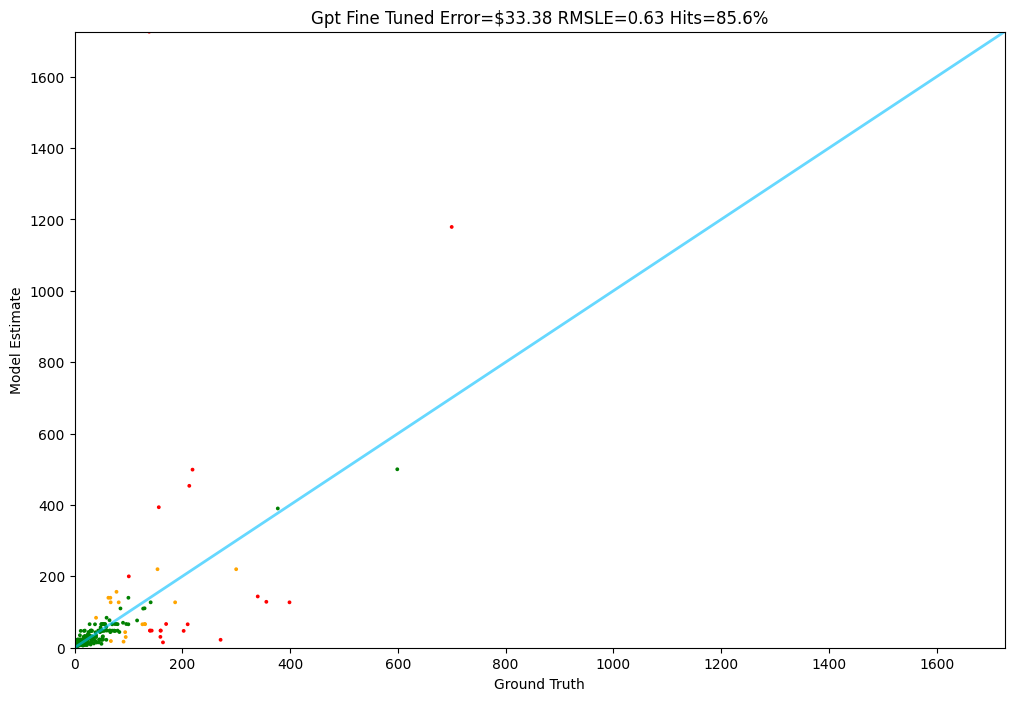

In [36]:
Tester.test(gpt_fine_tuned, test)